# Sentiment Analysis Project 
## Machine Learning, University of Rome Tor Vergata, academic year 2025/2026

## 1. Import of the main libraries

In [1]:
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download("stopwords", quiet=True)
np.random.seed(42)

## 2. Loading the datasets

In [2]:
imdb = pd.read_csv("data/imdb_labelled.txt", sep = "\t", header = None)
yelp = pd.read_csv("data/yelp_labelled.txt", sep = "\t", header = None)

# Set columns names
imdb.columns = ["sentence", "label"]
yelp.columns = ["sentence", "label"]

# Merge the datasets and mix them
df = pd.concat([imdb, yelp], ignore_index = True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Remove corrupted rows (very long sentences due to parsing errors)
df = df[df["sentence"].str.len() < 1000]

# Shows first 10 rows
df.head(10)

,sentence,label
0,Shrimp- When I unwrapped it (I live only 1/2 a...,0
1,Very bad Experience!,0
2,"Plus, with the movie's rather modest budget an...",1
3,I certainly do not mean this distinction in a ...,0
4,there are so many problems i dont know where t...,0
5,Which are small and not worth the price.,0
6,They will customize your order any way you'd l...,1
7,I was left shattered from the experience of wa...,0
9,But the duet between the astronaut and his doc...,1
10,For people who are first timers in film making...,1


## 3. Exploratory Data Analysis

In [3]:
# Number of sentences and columns in the dataset
print("Dataset shape:", df.shape)
print("Total sentences:", len(df))

Dataset shape: (1743, 2)
Total sentences: 1743


In [4]:
# Distribution of sentiment labels
label_counts = df["label"].value_counts()
print(label_counts)

label
1    884
0    859
Name: count, dtype: int64


In [5]:
# Sentence length statistics
df["sentence_length"] = df["sentence"].apply(len)
df["sentence_length"].describe()

count    1743.000000
mean       69.713138
std        46.677292
min         7.000000
25%        36.000000
50%        59.000000
75%        92.000000
max       479.000000
Name: sentence_length, dtype: float64

In [6]:
# Identify the longest sentence in the dataset
df.loc[df["sentence_length"].idxmax()]

sentence           This is a masterful piece of film-making, with...
label                                                              1
sentence_length                                                  479
Name: 277, dtype: object

In [7]:
# Remove extreme sentence length outliers
threshold = 300
print("Before:", df.shape)
df = df[df["sentence_length"] <= threshold].copy()
print("After:", df.shape)
# Recalculating sentence length
df["sentence_length"] = df["sentence"].apply(len)
# Updated statistics
df["sentence_length"].describe()
# Class distribution control
df["label"].value_counts()

Before: (1743, 3)
After: (1738, 3)


label
1    880
0    858
Name: count, dtype: int64

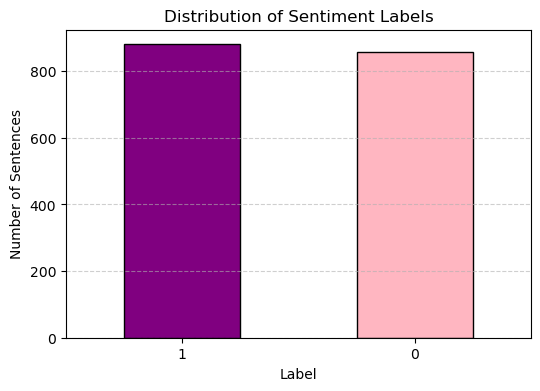

In [8]:
plt.figure(figsize=(6,4))

df["label"].value_counts().plot(kind="bar", color=["purple","lightpink"], edgecolor="black")

plt.title("Distribution of Sentiment Labels")
plt.xlabel("Label")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

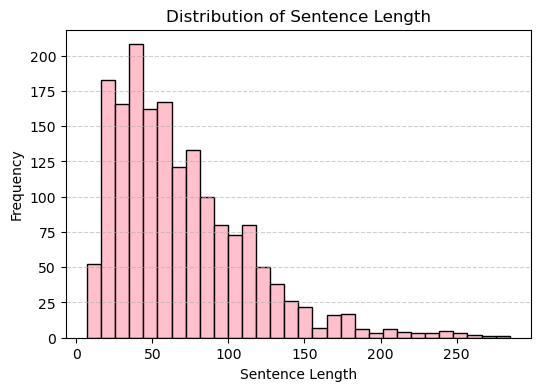

In [9]:
# Histogram of sentence lengths
plt.figure(figsize=(6,4))

plt.hist(df["sentence_length"], bins=30, color="pink", edgecolor="black")

plt.title("Distribution of Sentence Length")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

### EDA Summary

In [10]:
# Remove the column used only for exploratory analysis
df = df.drop(columns=["sentence_length"])

print("Final dataset shape:", df.shape)

Final dataset shape: (1738, 2)


## 4. Data Pre-processing


In [11]:
# Check for missing values
df.isnull().sum()

sentence    0
label       0
dtype: int64

In [12]:
# Base English stopwords
stop_words_base = set(stopwords.words("english"))

def build_stopwords(preserve_negations=True):
    stop_words = set(stop_words_base)
    if preserve_negations:
        stop_words = stop_words - {"not", "no", "nor"}
    return stop_words

def clean_text(text, stop_words):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenize the sentence
    words = text.split()
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Join words back into a sentence
    text = " ".join(words)
    # Normalize multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

stop_words = build_stopwords(preserve_negations=True)

In [13]:
X = df["sentence"]
y = df["label"]

In [14]:
#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 1390
Test samples: 348


In [15]:
X_train = X_train.apply(lambda x: clean_text(x, stop_words))
X_test = X_test.apply(lambda x: clean_text(x, stop_words))

In [16]:
print("Training label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Training label distribution:
label
1    704
0    686
Name: count, dtype: int64

Test label distribution:
label
1    176
0    172
Name: count, dtype: int64


## 5. Text Vectorization

In [17]:
# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    max_features=3000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

In [18]:
# Learn the vocabulary from the training set and transform the text into vectors
X_train_vec = vectorizer.fit_transform(X_train)

# Transform the test set using the same vocabulary
X_test_vec = vectorizer.transform(X_test)

In [19]:
# Show the shape of the resulting feature matrices
print("Training matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

Training matrix shape: (1390, 1506)
Test matrix shape: (348, 1506)


In [20]:
# Show the size of the vocabulary
print("Vocabulary size:", len(vectorizer.vocabulary_))

Vocabulary size: 1506


In [21]:
# Show some words from the learned vocabulary
feature_names = vectorizer.get_feature_names_out()

print("First 20 words in the vocabulary:")
print(feature_names[:20])

First 20 words in the vocabulary:
['absolutely' 'absolutely amazing' 'absolutely no' 'acknowledged' 'acted'
 'acting' 'action' 'action scenes' 'actor' 'actors' 'actress' 'actresses'
 'actually' 'adaptation' 'added' 'advise' 'afraid' 'africa' 'age' 'ago']


In [22]:
# Show an example of a cleaned sentence used for vectorization
print("Example cleaned sentence:")
print(X_train.iloc[0])

Example cleaned sentence:
service great even manager came helped table


In [23]:
# Compute aggregate TF-IDF scores in the training set
feature_scores = X_train_vec.sum(axis=0).A1
vocab = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    "feature": vocab,
    "score": feature_scores
}).sort_values(by="score", ascending=False)

word_freq.head(10)

,feature,score
877,not,33.619273
556,good,31.665479
829,movie,27.162799
968,place,26.692696
493,food,26.665620
572,great,25.315485
458,film,25.060256
1164,service,23.037511
85,bad,19.396730
907,one,17.138398


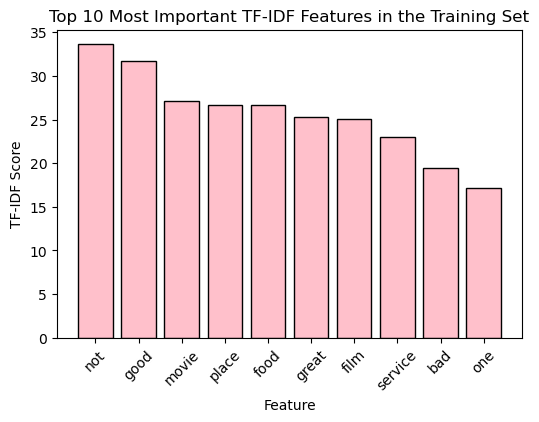

In [24]:
top_words = word_freq.head(10)

plt.figure(figsize=(6,4))
plt.bar(top_words["feature"], top_words["score"], edgecolor="black", color="pink")
plt.title("Top 10 Most Important TF-IDF Features in the Training Set")
plt.xlabel("Feature")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)
plt.show()

## 6. Model Training (Naive Bayes)



In [25]:
# Initialize the model
nb_model = MultinomialNB(alpha=1.0)

# Train the model on the training data
_ = nb_model.fit(X_train_vec, y_train)

## 7. Model Evaluation (Naive Bayes)

In [26]:
# Predict on the test set
nb_predictions = nb_model.predict(X_test_vec)

# Compute accuracy on the test set
nb_accuracy = accuracy_score(y_test, nb_predictions)

print(f"Naive Bayes Test Accuracy: {nb_accuracy:.4f}")

# Detailed evaluation
print("Classification Report:\n")
print(classification_report(y_test, nb_predictions))

Naive Bayes Test Accuracy: 0.8305
Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       172
           1       0.82      0.85      0.84       176

    accuracy                           0.83       348
   macro avg       0.83      0.83      0.83       348
weighted avg       0.83      0.83      0.83       348



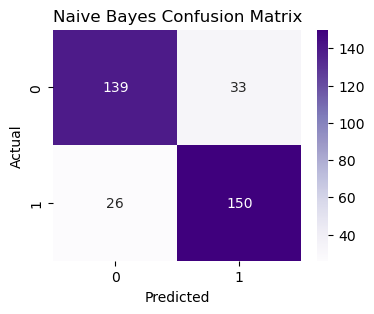

In [27]:
cm_nb = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(4,3))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
# Predictions on training set
nb_train_predictions = nb_model.predict(X_train_vec)

# Training accuracy
nb_train_accuracy = accuracy_score(y_train, nb_train_predictions)

print(f"Training Accuracy: {nb_train_accuracy:.4f}")
print(f"Test Accuracy: {nb_accuracy:.4f}")
print(f"Difference: {nb_train_accuracy - nb_accuracy:.4f}")

Training Accuracy: 0.9410
Test Accuracy: 0.8305
Difference: 0.1105


In [29]:
# Test on new custom sentences
sentences = ["The movie was amazing and very enjoyable", "The service was terrible and the food was awful"]

# Apply the same preprocessing used for the training data
cleaned_sentences = [clean_text(sentence, stop_words) for sentence in sentences]

# Transform the cleaned sentences using the same vectorizer
sentences_vectorized = vectorizer.transform(cleaned_sentences)

# Predict sentiment
predictions = nb_model.predict(sentences_vectorized)

for sentence, prediction in zip(sentences, predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"
    print(f"Sentence: {sentence}")
    print(f"Predicted sentiment: {sentiment}\n")

Sentence: The movie was amazing and very enjoyable
Predicted sentiment: Positive

Sentence: The service was terrible and the food was awful
Predicted sentiment: Negative



## 8. Model Training (Logistic Regression)

In [30]:
# Initialize the model
lr_model = LogisticRegression(max_iter=1000, C=0.3, solver="liblinear")

# Train the model on the training data
_ = lr_model.fit(X_train_vec, y_train)

## 9. Model Evaluation (Logistic Regression)

In [31]:
# Predictions on test set
lr_predictions = lr_model.predict(X_test_vec)

# Compute accuracy on the test set
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"Logistic Regression Test Accuracy: {lr_accuracy:.4f}")

# Detailed evaluation
print("Classification Report:\n")
print(classification_report(y_test, lr_predictions))

Logistic Regression Test Accuracy: 0.8075
Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.77      0.80       172
           1       0.79      0.84      0.82       176

    accuracy                           0.81       348
   macro avg       0.81      0.81      0.81       348
weighted avg       0.81      0.81      0.81       348



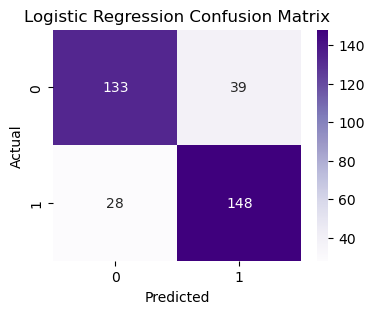

In [32]:
cm_lr = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(4,3))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
# Predictions on training set
lr_train_predictions = lr_model.predict(X_train_vec)

# Compute training accuracy
lr_train_accuracy = accuracy_score(y_train, lr_train_predictions)

print(f"Training Accuracy: {lr_train_accuracy:.4f}")
print(f"Test Accuracy: {lr_accuracy:.4f}")
print(f"Difference: {lr_train_accuracy - lr_accuracy:.4f}")

Training Accuracy: 0.9173
Test Accuracy: 0.8075
Difference: 0.1098


In [34]:
# Test Logistic Regression on new custom sentences

custom_sentences = [
    "The movie was amazing and very enjoyable",
    "The service was terrible and the food was awful"
]

# Apply same preprocessing
cleaned_custom = [clean_text(sentence, stop_words) for sentence in custom_sentences]

# Vectorize
custom_vectors = vectorizer.transform(cleaned_custom)

# Predict
lr_custom_predictions = lr_model.predict(custom_vectors)

for sentence, prediction in zip(custom_sentences, lr_custom_predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"
    print(f"Sentence: {sentence}")
    print(f"Predicted sentiment: {sentiment}\n")

Sentence: The movie was amazing and very enjoyable
Predicted sentiment: Positive

Sentence: The service was terrible and the food was awful
Predicted sentiment: Negative



## 10. Model Comparison

In [35]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Training Accuracy": [nb_train_accuracy, lr_train_accuracy],
    "Test Accuracy": [nb_accuracy, lr_accuracy]
})

results["Difference"] = results["Training Accuracy"] - results["Test Accuracy"]

results

,Model,Training Accuracy,Test Accuracy,Difference
0,Naive Bayes,0.941007,0.830460,0.110547
1,Logistic Regression,0.917266,0.807471,0.109795


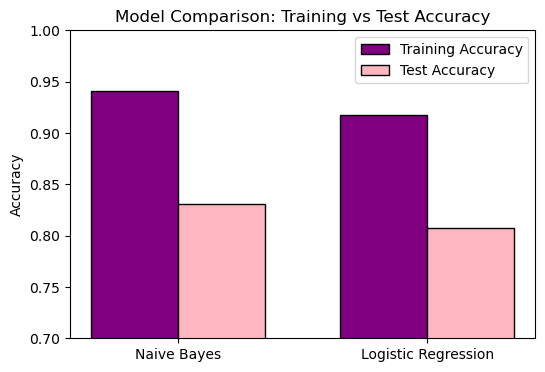

In [36]:
models = ["Naive Bayes", "Logistic Regression"]
train_acc = [nb_train_accuracy, lr_train_accuracy]
test_acc = [nb_accuracy, lr_accuracy]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(6,4))

# Plot training and test accuracy
plt.bar(x - width/2, train_acc, width, label='Training Accuracy', color='Purple', edgecolor="black")
plt.bar(x + width/2, test_acc, width, label='Test Accuracy', color='lightpink', edgecolor="black")

# Configure labels and title
plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Comparison: Training vs Test Accuracy")
plt.legend()

plt.ylim(0.7, 1.0)

plt.show()

## 11. Conclusion